100%|██████████| 778M/778M [00:06<00:00, 123MB/s]

Extracting files...


Total images: 750
Optimal r, alpha: [0.63637012 0.51191529]


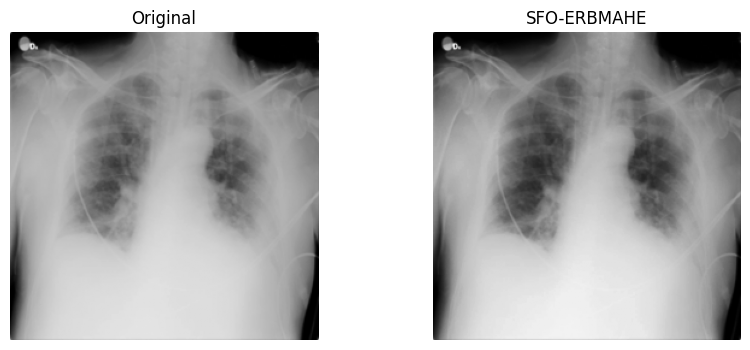

100%|██████████| 750/750 [00:10<00:00, 70.10it/s]


=========== FINAL SFO-ERBMAHE (600 IMAGES) ===========
Input Entropy       : 7.3181
Output Entropy      : 7.2760
PSNR                : 30.1589
AMBE                : 6.6592
ICF                 : 36.3432
Input LC            : 59.6915
Output LC           : 66.0620
SSIM                : 0.9442
FSIM                : 0.8129
TEN                 : 0.0723
QRCM                : 0.0406


In [1]:
# ============================================================
# FINAL SFO-ERBMAHE (600 CXR IMAGES)
# Sunflower Optimization + ERBMAHE
# ============================================================

import kagglehub
import os
import cv2
import numpy as np
from skimage.metrics import structural_similarity as ssim
from scipy.ndimage import sobel
from tqdm import tqdm
import random
import matplotlib.pyplot as plt

# ============================================================
# 1. LOAD DATASET
# ============================================================

DATASET_PATH = kagglehub.dataset_download(
    "tawsifurrahman/covid19-radiography-database"
)

BASE = os.path.join(DATASET_PATH, "COVID-19_Radiography_Dataset")

folders = [
    os.path.join(BASE, "COVID", "images"),
    os.path.join(BASE, "Normal", "images"),
    os.path.join(BASE, "Viral Pneumonia", "images")
]

image_paths = []
for folder in folders:
    files = sorted(os.listdir(folder))[:250]
    for f in files:
        image_paths.append(os.path.join(folder, f))

print("Total images:", len(image_paths))

# ============================================================
# 2. ERBMAHE
# ============================================================

def ERBMAHE(img, r, alpha):

    I = img.astype(np.uint8)

    hist = np.histogram(I.flatten(), 256, (0,256))[0]
    pdf = hist / (np.sum(hist) + 1e-8)

    pmin, pmax = pdf.min(), pdf.max()
    x = (pdf - pmin) / (pmax - pmin + 1e-8)

    Pw = (x ** r)
    Pw = Pw / (np.sum(Pw) + 1e-8)

    cdf = np.cumsum(Pw)
    enhanced = np.floor(255 * cdf[I]).astype(np.uint8)

    enhanced = np.clip(alpha*enhanced + (1-alpha)*I, 0, 255).astype(np.uint8)

    return enhanced

# ============================================================
# 3. METRICS
# ============================================================

def entropy(img):
    hist = np.histogram(img.flatten(), 256, (0,256))[0]
    p = hist / (np.sum(hist) + 1e-12)
    p = p[p > 0]
    return -np.sum(p * np.log2(p))

def psnr(i,o):
    mse = np.mean((i-o)**2)
    return 20*np.log10(255/np.sqrt(mse)) if mse>0 else 100

def ambe(i,o):
    return abs(np.mean(i)-np.mean(o))

def icf(img):
    return 10*np.log10(np.var(img)+1e-8)

def lc(img):
    return np.std(img)

def ten(img):
    gx = sobel(img.astype(float),axis=0)
    gy = sobel(img.astype(float),axis=1)
    return np.mean(gx**2 + gy**2) / (255**2)

def qrcm(i,o):
    return np.mean(np.abs(o.astype(float)-i.astype(float))) / 255

def fsim(i,o):
    gi = np.sqrt(sobel(i.astype(float),axis=0)**2 +
                 sobel(i.astype(float),axis=1)**2)

    go = np.sqrt(sobel(o.astype(float),axis=0)**2 +
                 sobel(o.astype(float),axis=1)**2)

    return np.sum(np.minimum(gi,go)) / (np.sum(np.maximum(gi,go))+1e-8)

# ============================================================
# 4. FITNESS FUNCTION
# ============================================================

def fitness(images, r, alpha):

    scores = []

    for img in images:

        out = ERBMAHE(img, r, alpha)

        E = entropy(out)
        P = psnr(img,out)/40
        A = 1/(1+ambe(img,out))
        C = icf(out)/50
        L = lc(out)/100
        S = ssim(img,out,data_range=255)
        F = fsim(img,out)
        T = ten(out)
        Q = 1 - qrcm(img,out)

        score = (E+P+A+C+L+S+F+T+Q)/9
        scores.append(score)

    return np.mean(scores)

# ============================================================
# 5. SUNFLOWER OPTIMIZATION (SFO)
# ============================================================

population = 50
iterations = 25
bounds = [(0.3,1.2),(0.5,1.0)]

# sample images for optimization
sample_imgs = []
for p in image_paths[:10]:
    img = cv2.imread(p,0)
    img = cv2.resize(img,(256,256))
    sample_imgs.append(img)

# initialize sunflowers
sunflowers = np.array([
    [random.uniform(*bounds[0]), random.uniform(*bounds[1])]
    for _ in range(population)
])

best_pos = sunflowers[0]
best_score = fitness(sample_imgs, best_pos[0], best_pos[1])

for t in range(iterations):

    for i in range(population):

        score = fitness(sample_imgs,
                        sunflowers[i][0],
                        sunflowers[i][1])

        if score > best_score:
            best_score = score
            best_pos = sunflowers[i].copy()

    # update positions toward best sunflower (sun movement)
    for i in range(population):

        distance = best_pos - sunflowers[i]
        step = np.random.uniform(0,1,2) * distance

        sunflowers[i] += step

        # random pollination factor
        if random.random() < 0.2:
            sunflowers[i] += np.random.uniform(-0.1,0.1,2)

        sunflowers[i][0] = np.clip(sunflowers[i][0], *bounds[0])
        sunflowers[i][1] = np.clip(sunflowers[i][1], *bounds[1])

print("Optimal r, alpha:", best_pos)

# ============================================================
# 6. DISPLAY ONE IMAGE
# ============================================================

sample_img = cv2.imread(image_paths[0],0)
sample_img = cv2.resize(sample_img,(256,256))
enhanced_img = ERBMAHE(sample_img, best_pos[0], best_pos[1])

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(sample_img,cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(enhanced_img,cmap='gray')
plt.title("SFO-ERBMAHE")
plt.axis("off")
plt.show()

# ============================================================
# 7. APPLY TO ALL 600 IMAGES
# ============================================================

metrics = np.zeros(11)

for path in tqdm(image_paths):

    img = cv2.imread(path,0)
    img = cv2.resize(img,(256,256))

    out = ERBMAHE(img, best_pos[0], best_pos[1])

    vals = [
        entropy(img),
        entropy(out),
        psnr(img,out),
        ambe(img,out),
        icf(out),
        lc(img),
        lc(out),
        ssim(img,out,data_range=255),
        fsim(img,out),
        ten(out),
        qrcm(img,out)
    ]

    metrics += np.array(vals)

metrics /= len(image_paths)

labels = [
    "Input Entropy","Output Entropy","PSNR","AMBE",
    "ICF","Input LC","Output LC",
    "SSIM","FSIM","TEN","QRCM"
]

print("\n=========== FINAL SFO-ERBMAHE (600 IMAGES) ===========")
for l,v in zip(labels,metrics):
    print(f"{l:20s}: {v:.4f}")


Using Colab cache for faster access to the 'covid19-radiography-database' dataset.
Using image: COVID-1.png

Optimal r, alpha: [0.4804016  0.71851482]


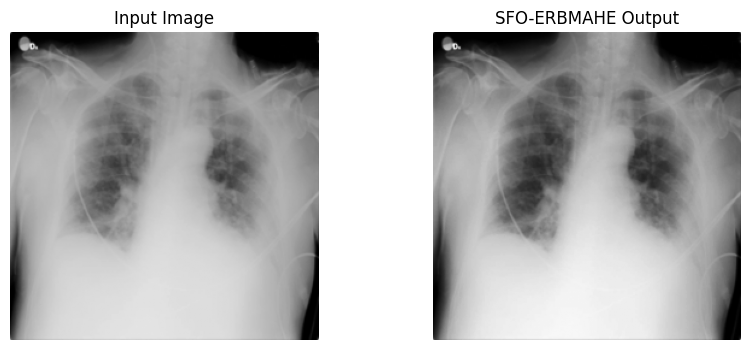

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


=========== METRICS ===========
Input Entropy : 7.1854785883247265
Output Entropy: 7.149995980025026
PSNR          : 29.019752005842676
AMBE          : 0.0007171630859375
ICF           : 36.05903968530694
Input LC      : 51.776677350754774
Output LC     : 63.52606933459704
SSIM          : 0.9578718323684612
FSIM          : 0.724014777771815
TEN           : 0.02748521639814014
QRCM          : 0.05317735858992034


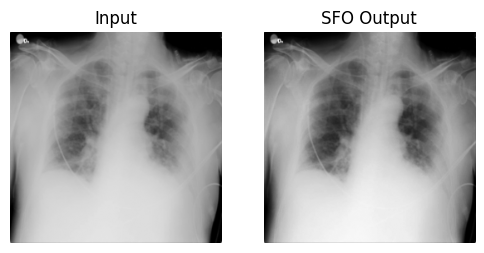

In [2]:
# ============================================================
# FINAL SFO-ERBMAHE (SINGLE COVID IMAGE)
# WITH INPUT + OUTPUT DOWNLOAD
# ============================================================

import kagglehub
import os
import cv2
import numpy as np
from skimage.metrics import structural_similarity as ssim
from scipy.ndimage import sobel
import random
import matplotlib.pyplot as plt
from google.colab import files

# ============================================================
# 1. LOAD ONE COVID IMAGE
# ============================================================

DATASET_PATH = kagglehub.dataset_download(
    "tawsifurrahman/covid19-radiography-database"
)

BASE = os.path.join(DATASET_PATH, "COVID-19_Radiography_Dataset")
covid_folder = os.path.join(BASE, "COVID", "images")

covid_file = sorted(os.listdir(covid_folder))[0]
image_path = os.path.join(covid_folder, covid_file)

print("Using image:", covid_file)

img_original = cv2.imread(image_path, 0)
img_original = cv2.resize(img_original, (256,256))

# ============================================================
# 2. ERBMAHE ENHANCEMENT
# ============================================================

def ERBMAHE(img, r, alpha):
    I = img.astype(np.uint8)

    hist = np.histogram(I.flatten(), 256, (0,256))[0]
    pdf = hist / (np.sum(hist) + 1e-8)

    pmin, pmax = pdf.min(), pdf.max()
    x = (pdf - pmin) / (pmax - pmin + 1e-8)

    Pw = (x ** r)
    Pw = Pw / (np.sum(Pw) + 1e-8)

    cdf = np.cumsum(Pw)
    enhanced = np.floor(255 * cdf[I]).astype(np.uint8)

    enhanced = np.clip(alpha*enhanced + (1-alpha)*I, 0, 255).astype(np.uint8)

    return enhanced

# ============================================================
# 3. METRICS
# ============================================================

def entropy(img):
    hist = np.histogram(img.flatten(), 256, (0,256))[0]
    p = hist / (np.sum(hist) + 1e-12)
    p = p[p > 0]
    return -np.sum(p * np.log2(p))

def psnr(i,o):
    mse = np.mean((i-o)**2)
    return 20*np.log10(255/np.sqrt(mse)) if mse>0 else 100

def ambe(i,o):
    return abs(np.mean(i)-np.mean(o))

def icf(img):
    return 10*np.log10(np.var(img)+1e-8)

def lc(img):
    return np.std(img)

def ten(img):
    gx = sobel(img.astype(float),axis=0)
    gy = sobel(img.astype(float),axis=1)
    return np.mean(gx**2 + gy**2) / (255**2)

def qrcm(i,o):
    return np.mean(np.abs(o.astype(float)-i.astype(float))) / 255

def fsim(i,o):
    gi = np.sqrt(sobel(i.astype(float),axis=0)**2 +
                 sobel(i.astype(float),axis=1)**2)

    go = np.sqrt(sobel(o.astype(float),axis=0)**2 +
                 sobel(o.astype(float),axis=1)**2)

    return np.sum(np.minimum(gi,go)) / (np.sum(np.maximum(gi,go))+1e-8)

# ============================================================
# 4. FITNESS FUNCTION
# ============================================================

def fitness(img, r, alpha):
    out = ERBMAHE(img, r, alpha)

    E = entropy(out)
    P = psnr(img,out)/40
    A = 1/(1+ambe(img,out))
    C = icf(out)/50
    L = lc(out)/100
    S = ssim(img,out,data_range=255)
    F = fsim(img,out)
    T = ten(out)
    Q = 1 - qrcm(img,out)

    return (E+P+A+C+L+S+F+T+Q)/9

# ============================================================
# 5. SUNFLOWER OPTIMIZATION (SFO)
# ============================================================

population = 20
iterations = 15
bounds = [(0.3,1.2),(0.5,1.0)]

sunflowers = np.array([
    [random.uniform(*bounds[0]), random.uniform(*bounds[1])]
    for _ in range(population)
])

best_pos = sunflowers[0]
best_score = fitness(img_original, best_pos[0], best_pos[1])

for t in range(iterations):

    for i in range(population):
        score = fitness(img_original,
                        sunflowers[i][0],
                        sunflowers[i][1])

        if score > best_score:
            best_score = score
            best_pos = sunflowers[i].copy()

    for i in range(population):
        distance = best_pos - sunflowers[i]
        step = np.random.uniform(0,1,2) * distance
        sunflowers[i] += step

        if random.random() < 0.2:
            sunflowers[i] += np.random.uniform(-0.1,0.1,2)

        sunflowers[i][0] = np.clip(sunflowers[i][0], *bounds[0])
        sunflowers[i][1] = np.clip(sunflowers[i][1], *bounds[1])

print("\nOptimal r, alpha:", best_pos)

# ============================================================
# 6. APPLY ENHANCEMENT
# ============================================================

enhanced_img = ERBMAHE(img_original, best_pos[0], best_pos[1])

# ============================================================
# 7. DISPLAY RESULT
# ============================================================

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img_original, cmap='gray')
plt.title("Input Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(enhanced_img, cmap='gray')
plt.title("SFO-ERBMAHE Output")
plt.axis("off")

plt.show()

# ============================================================
# 8. SAVE + DOWNLOAD IMAGES
# ============================================================

# Save input and output images
plt.imsave('covid19_input.png', img_original, cmap='gray', dpi=300)
plt.imsave('covid19_sfo_output.png', enhanced_img, cmap='gray', dpi=300)

# Save comparison figure
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.imshow(img_original, cmap='gray')
plt.title("Input")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(enhanced_img, cmap='gray')
plt.title("SFO Output")
plt.axis('off')

plt.savefig('comparison.png', dpi=300, bbox_inches='tight')

# Download all images
files.download('covid19_input.png')
files.download('covid19_sfo_output.png')
files.download('comparison.png')

# ============================================================
# 9. METRICS OUTPUT
# ============================================================

print("\n=========== METRICS ===========")

print("Input Entropy :", entropy(img_original))
print("Output Entropy:", entropy(enhanced_img))
print("PSNR          :", psnr(img_original, enhanced_img))
print("AMBE          :", ambe(img_original, enhanced_img))
print("ICF           :", icf(enhanced_img))
print("Input LC      :", lc(img_original))
print("Output LC     :", lc(enhanced_img))
print("SSIM          :", ssim(img_original, enhanced_img, data_range=255))
print("FSIM          :", fsim(img_original, enhanced_img))
print("TEN           :", ten(enhanced_img))
print("QRCM          :", qrcm(img_original, enhanced_img))

Using Colab cache for faster access to the 'covid19-radiography-database' dataset.
Using image: Normal-1.png

Optimal r, alpha: [0.40964484 0.53392702]


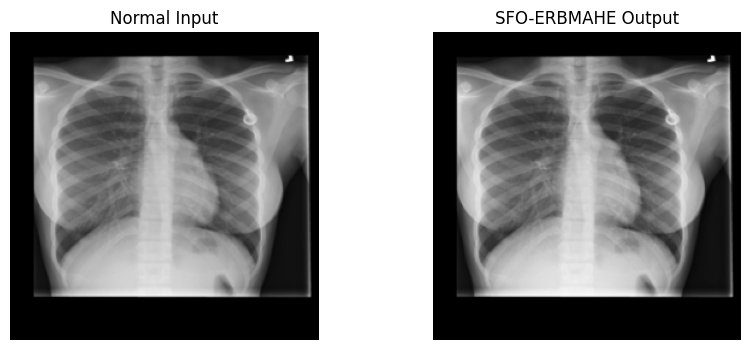

Images saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
# ============================================================
# FINAL SFO-ERBMAHE (NORMAL IMAGE)
# WITH INPUT + OUTPUT DOWNLOAD
# ============================================================

import kagglehub
import os
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from scipy.ndimage import sobel
from google.colab import files
import time

# ============================================================
# 1. LOAD NORMAL IMAGE
# ============================================================

DATASET_PATH = kagglehub.dataset_download(
    "tawsifurrahman/covid19-radiography-database"
)

BASE = os.path.join(DATASET_PATH, "COVID-19_Radiography_Dataset")
normal_folder = os.path.join(BASE, "Normal", "images")

normal_file = sorted(os.listdir(normal_folder))[0]
image_path = os.path.join(normal_folder, normal_file)

print("Using image:", normal_file)

img_original = cv2.imread(image_path, 0)
img_original = cv2.resize(img_original, (256,256))

# ============================================================
# 2. ERBMAHE FUNCTION
# ============================================================

def ERBMAHE(img, r, alpha):
    I = img.astype(np.uint8)

    hist = np.histogram(I.flatten(), 256, (0,256))[0]
    pdf = hist / (np.sum(hist) + 1e-8)

    x = (pdf - pdf.min()) / (pdf.max() - pdf.min() + 1e-8)
    Pw = (x ** r)
    Pw = Pw / (np.sum(Pw) + 1e-8)

    cdf = np.cumsum(Pw)
    enhanced = np.floor(255 * cdf[I]).astype(np.uint8)

    enhanced = np.clip(alpha*enhanced + (1-alpha)*I, 0, 255).astype(np.uint8)

    return enhanced

# ============================================================
# 3. FITNESS FUNCTION
# ============================================================

def entropy(img):
    hist = np.histogram(img.flatten(), 256, (0,256))[0]
    p = hist / (np.sum(hist) + 1e-12)
    p = p[p > 0]
    return -np.sum(p * np.log2(p))

def psnr(i,o):
    mse = np.mean((i-o)**2)
    return 20*np.log10(255/np.sqrt(mse)) if mse>0 else 100

def fitness(img, r, alpha):
    out = ERBMAHE(img, r, alpha)
    return entropy(out) + psnr(img,out)

# ============================================================
# 4. SFO OPTIMIZATION
# ============================================================

population = 10
iterations = 10
bounds = [(0.3,1.2),(0.5,1.0)]

sunflowers = np.array([
    [random.uniform(*bounds[0]), random.uniform(*bounds[1])]
    for _ in range(population)
])

best_pos = sunflowers[0]
best_score = fitness(img_original, best_pos[0], best_pos[1])

for _ in range(iterations):

    for i in range(population):
        score = fitness(img_original,
                        sunflowers[i][0],
                        sunflowers[i][1])

        if score > best_score:
            best_score = score
            best_pos = sunflowers[i].copy()

    for i in range(population):
        step = np.random.uniform(0,1,2) * (best_pos - sunflowers[i])
        sunflowers[i] += step

        if random.random() < 0.2:
            sunflowers[i] += np.random.uniform(-0.1,0.1,2)

        sunflowers[i][0] = np.clip(sunflowers[i][0], *bounds[0])
        sunflowers[i][1] = np.clip(sunflowers[i][1], *bounds[1])

print("\nOptimal r, alpha:", best_pos)

# ============================================================
# 5. APPLY ENHANCEMENT
# ============================================================

enhanced_img = ERBMAHE(img_original, best_pos[0], best_pos[1])

# ============================================================
# 6. DISPLAY
# ============================================================

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img_original, cmap='gray')
plt.title("Normal Input")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(enhanced_img, cmap='gray')
plt.title("SFO-ERBMAHE Output")
plt.axis("off")

plt.show()

# ============================================================
# 7. SAVE IMAGES
# ============================================================

plt.imsave('normal_input.png', img_original, cmap='gray', dpi=300)
plt.imsave('normal_output.png', enhanced_img, cmap='gray', dpi=300)

print("Images saved successfully!")

# ============================================================
# 8. AUTO DOWNLOAD (FIXED)
# ============================================================

time.sleep(2)
files.download('normal_input.png')

time.sleep(2)
files.download('normal_output.png')

Using Colab cache for faster access to the 'covid19-radiography-database' dataset.
Using image: Viral Pneumonia-1.png
Optimal parameters: [0.59944769 0.62223345]


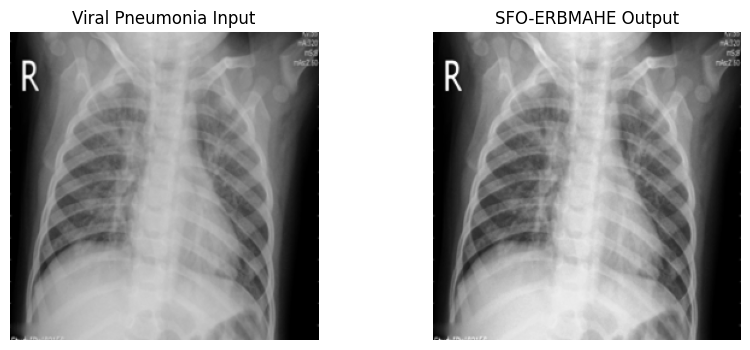

Images saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


=========== METRICS ===========
PSNR : 30.677043208935544
SSIM : 0.9482340617251751
FSIM : 0.7928200421183618


In [3]:
# ============================================================
# FINAL SFO-ERBMAHE (VIRAL PNEUMONIA IMAGE)
# WITH INPUT + OUTPUT DOWNLOAD
# ============================================================

import kagglehub
import os
import cv2
import numpy as np
from skimage.metrics import structural_similarity as ssim
from scipy.ndimage import sobel
import random
import matplotlib.pyplot as plt
from google.colab import files
import time

# ============================================================
# 1. LOAD IMAGE
# ============================================================

DATASET_PATH = kagglehub.dataset_download(
    "tawsifurrahman/covid19-radiography-database"
)

BASE = os.path.join(DATASET_PATH, "COVID-19_Radiography_Dataset")
vp_folder = os.path.join(BASE, "Viral Pneumonia", "images")

vp_file = sorted(os.listdir(vp_folder))[0]
image_path = os.path.join(vp_folder, vp_file)

print("Using image:", vp_file)

img_original = cv2.imread(image_path, 0)
img_original = cv2.resize(img_original, (256,256))

# ============================================================
# 2. ERBMAHE FUNCTION
# ============================================================

def ERBMAHE(img, r, alpha):
    hist = np.histogram(img.flatten(), 256, (0,256))[0]
    pdf = hist / (np.sum(hist) + 1e-8)

    x = (pdf - pdf.min()) / (pdf.max() - pdf.min() + 1e-8)
    Pw = (x ** r)
    Pw = Pw / (np.sum(Pw) + 1e-8)

    cdf = np.cumsum(Pw)
    enhanced = np.floor(255 * cdf[img]).astype(np.uint8)

    return np.clip(alpha*enhanced + (1-alpha)*img, 0, 255).astype(np.uint8)

# ============================================================
# 3. METRICS
# ============================================================

def entropy(img):
    hist = np.histogram(img.flatten(), 256, (0,256))[0]
    p = hist / (np.sum(hist) + 1e-12)
    p = p[p > 0]
    return -np.sum(p * np.log2(p))

def psnr(i,o):
    mse = np.mean((i-o)**2)
    return 20*np.log10(255/np.sqrt(mse)) if mse>0 else 100

def fsim(i,o):
    gi = np.sqrt(sobel(i.astype(float),axis=0)**2 +
                 sobel(i.astype(float),axis=1)**2)
    go = np.sqrt(sobel(o.astype(float),axis=0)**2 +
                 sobel(o.astype(float),axis=1)**2)
    return np.sum(np.minimum(gi,go)) / (np.sum(np.maximum(gi,go))+1e-8)

# ============================================================
# 4. FITNESS
# ============================================================

def fitness(img, r, alpha):
    out = ERBMAHE(img, r, alpha)
    return entropy(out) + psnr(img,out)

# ============================================================
# 5. SFO OPTIMIZATION
# ============================================================

population = 10
iterations = 10

sunflowers = np.array([
    [random.uniform(0.3,1.2), random.uniform(0.5,1.0)]
    for _ in range(population)
])

best = sunflowers[0]
best_score = fitness(img_original, best[0], best[1])

for _ in range(iterations):

    for i in range(population):
        score = fitness(img_original,
                        sunflowers[i][0],
                        sunflowers[i][1])
        if score > best_score:
            best_score = score
            best = sunflowers[i].copy()

    for i in range(population):
        step = np.random.rand(2) * (best - sunflowers[i])
        sunflowers[i] += step

        sunflowers[i][0] = np.clip(sunflowers[i][0], 0.3, 1.2)
        sunflowers[i][1] = np.clip(sunflowers[i][1], 0.5, 1.0)

print("Optimal parameters:", best)

# ============================================================
# 6. APPLY ENHANCEMENT
# ============================================================

enhanced_img = ERBMAHE(img_original, best[0], best[1])

# ============================================================
# 7. DISPLAY
# ============================================================

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img_original, cmap='gray')
plt.title("Viral Pneumonia Input")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(enhanced_img, cmap='gray')
plt.title("SFO-ERBMAHE Output")
plt.axis("off")

plt.show()

# ============================================================
# 8. SAVE IMAGES
# ============================================================

plt.imsave('viral_input.png', img_original, cmap='gray', dpi=300)
plt.imsave('viral_output.png', enhanced_img, cmap='gray', dpi=300)

print("Images saved successfully!")

# ============================================================
# 9. AUTO DOWNLOAD (FIXED)
# ============================================================

time.sleep(2)
files.download('viral_input.png')

time.sleep(2)
files.download('viral_output.png')

# ============================================================
# 10. METRICS OUTPUT
# ============================================================

print("\n=========== METRICS ===========")
print("PSNR :", psnr(img_original, enhanced_img))
print("SSIM :", ssim(img_original, enhanced_img, data_range=255))
print("FSIM :", fsim(img_original, enhanced_img))